# MADA - Fase 3: Experimento Sintético

**Metodologia de Identificação de Viés Amplificado**

Este notebook contempla a fase do estudo que abrange a geração e avaliação de datasets sintéticos, com níveis controlados de concordância entre anotadores, para detectar a amplificação de viés proposta pela metodologia.

### Conferencia do ambiente (Local x Colab)

In [1]:
import os
import sys

# 1. Detectar se o ambiente é o Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Ambiente detectado: Google Colab")
    REPO_URL = "https://github.com/alexfeitosa72/MIVA.git"
    REPO_NAME = "MIVA"

    # Clonar apenas se a pasta ainda não existir no ambiente virtual do Colab
    if not os.path.exists(REPO_NAME):
        print(f"📥 Clonando {REPO_NAME}...")
        !git clone {REPO_URL}
    
    # Entrar na pasta do repositório no Colab
    if os.getcwd().split('/')[-1] != REPO_NAME:
        os.chdir(REPO_NAME)
    
    print(f"Diretório de trabalho ajustado: {os.getcwd()}")
else:
    print(f"Ambiente detectado: Local (VS Code/Jupyter)")
    print(f"Mantendo diretório atual: {os.getcwd()}")

# 2. Listar arquivos de forma compatível (funciona em Windows, Mac, Linux e Colab)
print("\nArquivos na pasta raiz:")
print(os.listdir('.'))

Ambiente detectado: Local (VS Code/Jupyter)
Mantendo diretório atual: b:\TechLab\MIVA

Arquivos na pasta raiz:
['.claude', '.git', '.lh', '.vscode', 'analise_empates_duplos.ipynb', 'data', 'fase1_tratamento_logs.ipynb', 'fase2_dados_empiricos.ipynb', 'fase2_dados_empiricos_old.ipynb', 'fase3_dados_sinteticos.ipynb', 'fase3_dados_sinteticos_old.ipynb', 'legado', 'prisma2020.py', 'prisma_2020_dissertacao.pdf', 'prisma_2020_dissertacao.png', 'prisma_2020_dissertacao.svg', 'prisma_flow.pdf', 'prisma_flow.svg', 'prisma_values.json', 'resultados_MADA.ipynb', 'script_prisma.py', 'verificacao_rf_sintetico.py', 'xtra_analise_qualitativa.ipynb', '_refs']


## 1. Setup e Configurações

In [2]:
# Importações
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)
from sklearn.base import clone

# Análise estatística
from scipy.stats import chi2_contingency

# Visualização
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Configurações
warnings.filterwarnings('ignore')

# ============================================================================
# ESTILO ACADÊMICO NATURE (azulado) - Mesma paleta da Fase 2
# ============================================================================
plt.style.use('seaborn-v0_8-whitegrid')

NATURE_BLUE = '#0C4A6E'
NATURE_BLUE_MED = '#0284C7'
NATURE_BLUE_LIGHT = '#38BDF8'
NATURE_GRAY = '#64748B'
NATURE_ACCENT = '#1E3A5F'

NATURE_PALETTE = [NATURE_BLUE, NATURE_BLUE_MED, NATURE_BLUE_LIGHT, NATURE_GRAY]

CORES_MODELOS_NATURE = {
    'SVM': '#0C4A6E',
    'NB': '#0284C7',
    'RF': '#0EA5E9',
    'LR': '#38BDF8'
}

COR_NEGATIVA = '#DC2626'
COR_NEUTRA = '#6B7280'
COR_POSITIVA = '#0284C7'

SEV_COLORS = {
    'Nulo': '#6B7280',
    'Restrito': '#0284C7',
    'Amplo': '#F59E0B',
    'Acentuado': '#DC2626'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

sns.set_palette(NATURE_PALETTE)
pd.options.display.float_format = '{:.4f}'.format

SEED = 42
np.random.seed(SEED)   # cinto de seguranca; reprodutibilidade NAO depende mais
                       # do estado global (geracao e bootstraps usam default_rng isolado)

print("[OK] Bibliotecas importadas com sucesso.")
print("[OK] Estilo acadêmico Nature aplicado.")


[OK] Bibliotecas importadas com sucesso.
[OK] Estilo acadêmico Nature aplicado.


In [3]:
N_FOLDS = 5

DATA_DIR = Path("data")
SINTETICOS_DIR = DATA_DIR / "sinteticos"
RESULTS_DIR = DATA_DIR / "resultados_sinteticos"
GRAFICOS_DIR = RESULTS_DIR / "graficos_sinteticos"

SINTETICOS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAFICOS_DIR.mkdir(parents=True, exist_ok=True)

CLASSE_MAP = {'negativa': -1, 'neutra': 0, 'positiva': 1}
CLASSE_REVERSO = {v: k for k, v in CLASSE_MAP.items()}

print("=" * 80)
print("CONFIGURAÇÕES")
print("=" * 80)
print(f"Seed: {SEED}")
print(f"K-Fold CV: {N_FOLDS} folds")
print(f"Diretórios criados.")
print("=" * 80)


CONFIGURAÇÕES
Seed: 42
K-Fold CV: 5 folds
Diretórios criados.


In [4]:
# Modelos de classificação (hiperparâmetros padrão - mesmos da Fase 2)
modelos = {
    'SVM': SVC(kernel='linear', C=1.0, random_state=SEED),
    'NB': MultinomialNB(alpha=1.0),
    'RF': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'LR': LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
}

print("="*80)
print("MODELOS CONFIGURADOS")
print("="*80)
for nome, modelo in modelos.items():
    params = modelo.get_params()
    params_rel = {k: v for k, v in params.items() 
                  if k in ['C', 'alpha', 'kernel', 'n_estimators', 'solver', 'random_state']}
    print(f"\n{nome}:")
    for param, valor in params_rel.items():
        print(f"    {param}: {valor}")

MODELOS CONFIGURADOS

SVM:
    C: 1.0
    kernel: linear
    random_state: 42

NB:
    alpha: 1.0

RF:
    n_estimators: 100
    random_state: 42

LR:
    C: 1.0
    random_state: 42
    solver: lbfgs


In [5]:
# ============================================================================
# CRITÉRIO LANDIS & KOCH (1977) - Para comparabilidade com Fase 2
# ============================================================================

LK_BANDS = [
    ('Poor', -1.0, 0.0),
    ('Slight', 0.0, 0.20),
    ('Fair', 0.20, 0.40),
    ('Moderate', 0.40, 0.60),
    ('Substantial', 0.60, 0.80),
    ('Almost Perfect', 0.80, 1.00),
]

LK_RANK = {name: i for i, (name, _, _) in enumerate(LK_BANDS)}


def obter_faixa_landis_koch(kappa):
    """Retorna a faixa de concordância segundo Landis & Koch (1977)."""
    if pd.isna(kappa):
        return np.nan
    for name, low, high in LK_BANDS:
        if kappa <= high:
            return name
    return 'Almost Perfect'


def classificar_severidade_por_queda_de_faixas(kappa_anot, kappa_pred):
    """Classifica severidade pela queda de faixas de concordância (Landis & Koch, 1977)."""
    faixa_inicial = obter_faixa_landis_koch(kappa_anot)
    faixa_modelo = obter_faixa_landis_koch(kappa_pred)

    faixas_perdidas = max(0, LK_RANK.get(faixa_inicial, 0) - LK_RANK.get(faixa_modelo, 0))

    SEVERIDADE = {0: "Nulo", 1: "Restrito", 2: "Amplo"}
    severidade = SEVERIDADE.get(faixas_perdidas, "Acentuado")

    return severidade, faixas_perdidas, faixa_inicial, faixa_modelo


print("[OK] Critério Landis & Koch (1977) configurado.")


[OK] Critério Landis & Koch (1977) configurado.


## 2. Geração dos Datasets Sintéticos

Cada dataset SynSA-XX contém 999 instâncias (3 classes × 333) com concordância controlada γ.
Textos sintéticos com tokens placeholder (word1, word2, ...) de 20 a 100 palavras.

In [6]:
def gerar_pares_rotulos_balanceados(classes, n_por_classe, gamma):
    """
    GenerateBalancedLabelPairs (Algorithm 1, Linha 3)
    
    Gera pares de rótulos (masculino, feminino) com:
    - Distribuição perfeitamente balanceada entre classes para AMBOS os gêneros
    - Taxa de concordância controlada por gamma
    
    Parâmetros:
    -----------
    classes : list
        Classes de sentimento (ex: ['negativa', 'neutra', 'positiva'])
    n_por_classe : int
        Número de instâncias por classe (N/3)
    gamma : float
        Taxa de concordância desejada entre 0 e 1
    
    Retorna:
    --------
    rotulos_masc, rotulos_fem : np.array, np.array
    """
    N = n_por_classe * len(classes)
    n_concordantes = int(round(gamma * N))
    n_discordantes = N - n_concordantes
    
    rotulos_masc = []
    rotulos_fem = []
    
    # --- Parte concordante: rótulos idênticos, balanceados ---
    # Distribui igualmente entre as 3 classes
    conc_por_classe = n_concordantes // len(classes)
    resto_conc = n_concordantes % len(classes)
    
    for i, cls in enumerate(classes):
        n = conc_por_classe + (1 if i < resto_conc else 0)
        rotulos_masc.extend([cls] * n)
        rotulos_fem.extend([cls] * n)
    
    # --- Parte discordante: rótulos diferentes, preservando balanço ---
    # Para cada instância discordante, o rótulo masculino e feminino
    # são de classes DIFERENTES, distribuídos para manter balanço global
    disc_por_classe = n_discordantes // len(classes)
    resto_disc = n_discordantes % len(classes)
    
    for i, cls in enumerate(classes):
        n = disc_por_classe + (1 if i < resto_disc else 0)
        outras_classes = [c for c in classes if c != cls]
        for j in range(n):
            rotulos_masc.append(cls)
            # Rótulo feminino: classe diferente, alternando entre as outras
            rotulos_fem.append(outras_classes[j % len(outras_classes)])
    
    return np.array(rotulos_masc), np.array(rotulos_fem)


def gerar_textos_sinteticos(N, L_min=20, L_max=100, rng=None):
    """
    GenerateSyntheticTexts (Algorithm 1, Linha 4)
    
    Gera N textos sintéticos com tokens placeholder.
    Cada texto tem entre L_min e L_max tokens.
    
    Os textos são semanticamente neutros — o objetivo é isolar
    o efeito dos rótulos no comportamento dos classificadores.
    
    A aleatoriedade usa um gerador isolado (np.random.default_rng),
    sem tocar no estado global do NumPy, garantindo reprodutibilidade
    independente da ordem de execução das células.
    """
    if rng is None:
        rng = np.random.default_rng(SEED)
    textos = []
    for i in range(N):
        n_tokens = rng.integers(L_min, L_max + 1)
        tokens = [f"word{rng.integers(1, 501)}" for _ in range(n_tokens)]
        textos.append(' '.join(tokens))
    return textos


def gerar_dataset_sintetico(gamma, N=999, L_min=20, L_max=100, seed=SEED):
    """
    AssembleDataset + Shuffle (Algorithm 1, Linhas 5-7)
    
    Gera um dataset sintético completo SynSA-XX.
    
    Parâmetros:
    -----------
    gamma : float
        Taxa de concordância (0.50 a 0.99)
    N : int
        Número total de instâncias (múltiplo de 3)
    L_min, L_max : int
        Comprimento mínimo e máximo dos textos
    seed : int
        Seed para reprodutibilidade
    
    Retorna:
    --------
    pd.DataFrame com colunas: texto, rotulo_masculino, rotulo_feminino
    """
    rng = np.random.default_rng(seed)   # gerador isolado; nao altera o estado global
    
    classes = ['negativa', 'neutra', 'positiva']
    n_por_classe = N // len(classes)
    
    # Linha 3: pares de rótulos balanceados com concordância γ (deterministico)
    rotulos_masc, rotulos_fem = gerar_pares_rotulos_balanceados(
        classes, n_por_classe, gamma
    )
    
    # Linha 4: textos sintéticos
    textos = gerar_textos_sinteticos(N, L_min, L_max, rng=rng)
    
    # Linhas 5-6: montagem e shuffle
    df = pd.DataFrame({
        'texto': textos,
        'rotulo_masculino': rotulos_masc,
        'rotulo_feminino': rotulos_fem
    })
    
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    return df


print("Funções de geração definidas.")

Funções de geração definidas.


In [7]:
# =============================================================================
# GERAÇÃO DOS 12 DATASETS SINTÉTICOS
# =============================================================================

# Níveis de concordância conforme o artigo
NIVEIS_CONCORDANCIA = [99, 97, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50]

datasets_sinteticos = {}

print("=" * 80)
print("GERAÇÃO DOS DATASETS SINTÉTICOS (SynSA-XX)")
print("=" * 80)

for nivel in NIVEIS_CONCORDANCIA:
    gamma = nivel / 100.0
    nome = f"SynSA-{nivel}"
    
    df = gerar_dataset_sintetico(gamma=gamma, N=999, seed=SEED)
    datasets_sinteticos[nome] = df
    
    # Salvar CSV
    output_path = f"data/sinteticos/{nome}.csv"
    df.to_csv(output_path, index=False, encoding='utf-8')
    
    # Concordância efetiva
    conc_efetiva = (df['rotulo_masculino'] == df['rotulo_feminino']).mean() * 100
    
    print(f"  {nome}: γ={gamma:.2f} | N={len(df)} | "
          f"Concordância efetiva={conc_efetiva:.2f}% | Salvo: {output_path}")

print(f"\n✔ {len(datasets_sinteticos)} datasets gerados com sucesso.")

GERAÇÃO DOS DATASETS SINTÉTICOS (SynSA-XX)
  SynSA-99: γ=0.99 | N=999 | Concordância efetiva=99.00% | Salvo: data/sinteticos/SynSA-99.csv
  SynSA-97: γ=0.97 | N=999 | Concordância efetiva=97.00% | Salvo: data/sinteticos/SynSA-97.csv
  SynSA-95: γ=0.95 | N=999 | Concordância efetiva=94.99% | Salvo: data/sinteticos/SynSA-95.csv
  SynSA-90: γ=0.90 | N=999 | Concordância efetiva=89.99% | Salvo: data/sinteticos/SynSA-90.csv
  SynSA-85: γ=0.85 | N=999 | Concordância efetiva=84.98% | Salvo: data/sinteticos/SynSA-85.csv
  SynSA-80: γ=0.80 | N=999 | Concordância efetiva=79.98% | Salvo: data/sinteticos/SynSA-80.csv
  SynSA-75: γ=0.75 | N=999 | Concordância efetiva=74.97% | Salvo: data/sinteticos/SynSA-75.csv
  SynSA-70: γ=0.70 | N=999 | Concordância efetiva=69.97% | Salvo: data/sinteticos/SynSA-70.csv
  SynSA-65: γ=0.65 | N=999 | Concordância efetiva=64.96% | Salvo: data/sinteticos/SynSA-65.csv
  SynSA-60: γ=0.60 | N=999 | Concordância efetiva=59.96% | Salvo: data/sinteticos/SynSA-60.csv
  SynSA

In [8]:
# =============================================================================
# VALIDAÇÃO: DISTRIBUIÇÃO DE CLASSES E CONCORDÂNCIA
# =============================================================================

print("=" * 80)
print("VALIDAÇÃO DOS DATASETS SINTÉTICOS")
print("=" * 80)
print(f"{'Dataset':<12} {'Conc.(%)':<10} {'Masc(neg/neu/pos)':<22} {'Fem(neg/neu/pos)':<22}")
print("-" * 70)

for nome in [f"SynSA-{n}" for n in NIVEIS_CONCORDANCIA]:
    df = datasets_sinteticos[nome]
    
    conc = (df['rotulo_masculino'] == df['rotulo_feminino']).mean() * 100
    
    dist_m = df['rotulo_masculino'].value_counts().reindex(
        ['negativa', 'neutra', 'positiva'], fill_value=0
    )
    dist_f = df['rotulo_feminino'].value_counts().reindex(
        ['negativa', 'neutra', 'positiva'], fill_value=0
    )
    
    print(f"  {nome:<10} {conc:>7.2f}%   "
          f"{dist_m['negativa']:>3}/{dist_m['neutra']:>3}/{dist_m['positiva']:>3}       "
          f"{dist_f['negativa']:>3}/{dist_f['neutra']:>3}/{dist_f['positiva']:>3}")

VALIDAÇÃO DOS DATASETS SINTÉTICOS
Dataset      Conc.(%)   Masc(neg/neu/pos)      Fem(neg/neu/pos)      
----------------------------------------------------------------------
  SynSA-99     99.00%   334/333/332       334/333/332
  SynSA-97     97.00%   333/333/333       333/333/333
  SynSA-95     94.99%   334/333/332       334/333/332
  SynSA-90     89.99%   334/333/332       334/333/332
  SynSA-85     84.98%   333/333/333       333/333/333
  SynSA-80     79.98%   334/333/332       334/333/332
  SynSA-75     74.97%   334/333/332       334/333/332
  SynSA-70     69.97%   333/333/333       333/333/333
  SynSA-65     64.96%   334/333/332       334/333/332
  SynSA-60     59.96%   334/333/332       334/333/332
  SynSA-55     54.95%   333/333/333       333/333/333
  SynSA-50     50.05%   334/333/332       333/334/332


## 3. Treinamento Pareado e Avaliação

Mesma pipeline da Fase 2 (dados empíricos), adaptada para dados sintéticos:
* Mesmos 4 classificadores da Fase 2: SVM, NB, RF, LR
* 5-fold stratified cross-validation com splits idênticos entre modelos M e F
* Métricas: Cohen's κ, χ², Cramér's V, Δκ, Severidade (Landis & Koch, 1977)

In [9]:

# =============================================================================
# DEFINIÇÃO DOS CLASSIFICADORES E FUNÇÕES DE AVALIAÇÃO
# =============================================================================

# Stopwords em português — idêntica à Fase 2 (inócua nos dados sintéticos,
# mantida para garantir paridade de pipeline entre fases)
stopwords_pt = [
    'a', 'o', 'e', 'é', 'de', 'da', 'do', 'em', 'um', 'uma', 'os', 'as', 'dos', 'das',
    'ao', 'à', 'às', 'no', 'na', 'nos', 'nas', 'por', 'para', 'com', 'sem', 'sob', 'sobre',
    'que', 'se', 'me', 'te', 'lhe', 'como', 'mas', 'ou', 'quando', 'onde', 'qual', 'quais',
    'ele', 'ela', 'eles', 'elas', 'eu', 'tu', 'nós', 'vós', 'você', 'vocês',
    'meu', 'minha', 'meus', 'minhas', 'seu', 'sua', 'seus', 'suas', 'nosso', 'nossa',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela', 'isto', 'isso', 'aquilo',
    'foi', 'ser', 'ter', 'estar', 'fazer', 'ir', 'ver', 'dar', 'saber',
    'há', 'muito', 'mais', 'menos', 'bem', 'mal', 'já', 'ainda', 'só', 'também',
    'até', 'depois', 'antes', 'agora', 'então', 'aqui', 'ali', 'lá',
    'sim', 'não', 'nem', 'nunca', 'sempre', 'nada', 'tudo', 'todo', 'algum', 'nenhum'
]


def calcular_cramers_v(y1, y2):
    """Calcula Cramér's V a partir de duas séries categóricas."""
    tabela = pd.crosstab(y1, y2)
    chi2, p_value, dof, expected = chi2_contingency(tabela)
    n = len(y1)
    min_dim = min(tabela.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0, chi2, p_value
    return np.sqrt(chi2 / (n * min_dim)), chi2, p_value


def avaliar_concordancia_anotadores(df):
    """
    Calcula métricas de concordância entre anotadores sintéticos (M vs F).
    Equivalente à análise humano-humano da Fase 2 (MÓDULO I: Baseline).
    """
    y_masc = df['rotulo_masculino']
    y_fem = df['rotulo_feminino']

    kappa = cohen_kappa_score(y_masc, y_fem)
    cramers_v, chi2_stat, p_value = calcular_cramers_v(y_masc, y_fem)

    # Bootstrap para IC do kappa
    n_bootstrap = 10000
    n = len(y_masc)



    #v.4 — gerador isolado, semente fixa e explicita
    rng_boot = np.random.default_rng(SEED)
    kappas_bootstrap = []

    for _ in range(n_bootstrap):
        idx = rng_boot.choice(n, size=n, replace=True)
        kappa_sample = cohen_kappa_score(
            y_masc.iloc[idx],
            y_fem.iloc[idx]
        )
        kappas_bootstrap.append(kappa_sample)





    return {
        'Consenso (%)': (y_masc == y_fem).mean() * 100,
        'Cohen κ': kappa,
        'χ² (stat)': chi2_stat,
        'p-value': p_value,
        'Cramér V': cramers_v,
        'Kappa_IC95_Lower': np.percentile(kappas_bootstrap, 2.5),
        'Kappa_IC95_Upper': np.percentile(kappas_bootstrap, 97.5),
        'faixa_lk': obter_faixa_landis_koch(kappa)
    }


def treinar_e_comparar(df, nome_dataset):
    """
    Pipeline de treinamento e comparação de modelos por gênero.
    ALINHADA com a Fase 2 (empírica) para máxima comparabilidade.

    Para cada classificador:
    1. TF-IDF ajustado por fold (fit no treino, transform no teste)
    2. Loop manual de folds com stratificação por y_masc para AMBOS os modelos
    3. κ_pred = média dos kappas por fold
    4. Cramér's V e χ² sobre predições concatenadas
    5. Delta κ e severidade (Landis & Koch, 1977)
    6. Bootstrap para significância estatística do Delta κ

    Nota: nos dados sintéticos os tokens são amostrados de um vocabulário fixo
    de 500 termos com distribuição uniforme. O vocabulário aprendido por fold
    converge para o vocabulário completo por construção — os resultados são
    estáveis independentemente do momento do fit, o que serve como controle
    de robustez do protocolo.
    """
    # Parâmetros TF-IDF — idênticos à Fase 2.
    # O fit ocorre dentro do fold (ver loop abaixo).
    tfidf_params = dict(
        max_features=10000,
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.90,
        strip_accents=None,
        stop_words=stopwords_pt,
        sublinear_tf=True,
        use_idf=True,
        norm='l2'
    )

    textos = df['texto'].values
    y_masc = df['rotulo_masculino'].values
    y_fem  = df['rotulo_feminino'].values

    kappa_anot = cohen_kappa_score(df['rotulo_masculino'], df['rotulo_feminino'])

    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    resultados = {}

    for nome_clf, clf_base in modelos.items():
        kappas_folds  = []
        all_pred_masc = np.empty(len(y_masc), dtype=object)
        all_pred_fem  = np.empty(len(y_fem),  dtype=object)

        for fold, (train_idx, test_idx) in enumerate(cv.split(textos, y_masc)):

            # TF-IDF: fit APENAS nos dados de treino deste fold.
            # Ambos os modelos do par usam o mesmo vetorizador (ajustado em X_train),
            # preservando comparabilidade pareada sem expor dados de teste ao fit.
            tfidf = TfidfVectorizer(**tfidf_params)
            X_train = tfidf.fit_transform(textos[train_idx])
            X_test  = tfidf.transform(textos[test_idx])

            modelo_masc = clone(clf_base)
            modelo_masc.fit(X_train, y_masc[train_idx])
            pred_masc = modelo_masc.predict(X_test)

            modelo_fem = clone(clf_base)
            modelo_fem.fit(X_train, y_fem[train_idx])
            pred_fem = modelo_fem.predict(X_test)

            kappas_folds.append(cohen_kappa_score(pred_masc, pred_fem))
            all_pred_masc[test_idx] = pred_masc
            all_pred_fem[test_idx]  = pred_fem

        kappa     = np.mean(kappas_folds)
        kappa_std = np.std(kappas_folds)

        cramers_v, chi2_stat, p_value = calcular_cramers_v(
            pd.Series(all_pred_masc), pd.Series(all_pred_fem)
        )

        delta_kappa = kappa_anot - kappa
        severidade, faixas_perdidas, faixa_inicial, faixa_modelo = \
            classificar_severidade_por_queda_de_faixas(kappa_anot, kappa)

        # Bootstrap para IC do Δκ — gerador isolado, semente fixa e explicita
        n_bootstrap = 10000
        n = len(all_pred_masc)
        rng_boot = np.random.default_rng(SEED)
        deltas_bootstrap = []

        for _ in range(n_bootstrap):
            idx = rng_boot.choice(n, size=n, replace=True)
            kappa_sample = cohen_kappa_score(all_pred_masc[idx], all_pred_fem[idx])
            deltas_bootstrap.append(kappa_anot - kappa_sample)

        ci_lower = np.percentile(deltas_bootstrap, 2.5)
        ci_upper = np.percentile(deltas_bootstrap, 97.5)

        significativo = ci_lower > 0 or ci_upper < 0
        if ci_lower > 0:
            direcao = "AMPLIFICA"
        elif ci_upper < 0:
            direcao = "REDUZ"
        else:
            direcao = "NÃO SIGNIFICATIVO"

        resultados[nome_clf] = {
            'Cohen κ':               kappa,
            'Cohen κ std':           kappa_std,
            'χ² (stat)':             chi2_stat,
            'p-value':               p_value,
            'Cramér V':              cramers_v,
            'kappa_anot':         kappa_anot,
            'delta_kappa':           delta_kappa,
            'faixa_inicial_lk':      faixa_inicial,
            'faixa_modelo_lk':       faixa_modelo,
            'faixas_perdidas':       faixas_perdidas,
            'severidade':            severidade,
            'amplificacao_detectada': faixas_perdidas > 0,
            'delta_bootstrap_mean':  np.mean(deltas_bootstrap),
            'ic_95_lower':           ci_lower,
            'ic_95_upper':           ci_upper,
            'significativo':         significativo,
            'direcao':               direcao
        }

    return resultados


print("Funções de avaliação definidas (com Delta κ, Severidade e Bootstrap).")
print("* Pipeline ALINHADA com a Fase 2:")
print("  - TF-IDF: ngram=(1,3), max=10000, min_df=3, max_df=0.90, sublinear, stopwords_pt, norm=l2")
print("  - CV: loop manual de folds, stratificação por y_masc para AMBOS os modelos")
print("  - κ_pred: média dos kappas por fold (kappa_mean)")
print("  - Classificadores: SVM(C=1), NB(α=1), RF(n=100), LR(C=1, max_iter=1000)")


Funções de avaliação definidas (com Delta κ, Severidade e Bootstrap).
* Pipeline ALINHADA com a Fase 2:
  - TF-IDF: ngram=(1,3), max=10000, min_df=3, max_df=0.90, sublinear, stopwords_pt, norm=l2
  - CV: loop manual de folds, stratificação por y_masc para AMBOS os modelos
  - κ_pred: média dos kappas por fold (kappa_mean)
  - Classificadores: SVM(C=1), NB(α=1), RF(n=100), LR(C=1, max_iter=1000)


In [10]:
# =============================================================================
# EXECUÇÃO: TREINAMENTO E AVALIAÇÃO PARA TODOS OS 12 DATASETS
# =============================================================================

resultados_todos = {}       # {nome_dataset: {nome_clf: {métricas}}}
metricas_anotadores = {}    # {nome_dataset: {métricas anotadores}}

print("="*80)
print("TREINAMENTO E COMPARAÇÃO DE MODELOS POR GÊNERO")
print("="*80)

inicio_treino = datetime.now()

for nivel in NIVEIS_CONCORDANCIA:
    nome = f"SynSA-{nivel}"
    df = datasets_sinteticos[nome]
    
    print(f"\n{'─' * 70}")
    print(f"  Processando {nome} (γ = {nivel/100:.2f})")
    print(f"{'─' * 70}")
    
    # 1. Métricas anotadores (M vs F sintéticos) - MÓDULO I: Baseline
    met_anot = avaliar_concordancia_anotadores(df)
    metricas_anotadores[nome] = met_anot
    print(f"  Anotadores — κ: {met_anot['Cohen κ']:.4f} "
          f"({met_anot['faixa_lk']}) | "
          f"IC95%: [{met_anot['Kappa_IC95_Lower']:.4f}, {met_anot['Kappa_IC95_Upper']:.4f}]")
    print(f"  Anotadores — Cramér V: {met_anot['Cramér V']:.4f} | "
          f"χ²: {met_anot['χ² (stat)']:.2f}")
    
    # 2. Treinamento e comparação dos classificadores - MÓDULO II & III
    res_clf = treinar_e_comparar(df, nome)
    resultados_todos[nome] = res_clf
    
    print(f"\n  {'Modelo':<5} | {'κ_pred':<10} | {'Δκ':<10} | {'Faixas':<7} | {'Severidade':<12} | {'Signif.':<15}")
    print(f"  {'-'*68}")
    
    for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
        met = res_clf[clf_nome]
        print(f"  {clf_nome:<5} | {met['Cohen κ']:>10.4f} | "
              f"{met['delta_kappa']:>+10.4f} | {met['faixas_perdidas']:>7} | "
              f"{met['severidade']:<12} | {met['direcao']:<15}")

duracao = datetime.now() - inicio_treino

print(f"\n{'=' * 80}")
print(f"✔ Processamento concluído para todos os 12 datasets em {duracao}")
print(f"{'=' * 80}")

TREINAMENTO E COMPARAÇÃO DE MODELOS POR GÊNERO

──────────────────────────────────────────────────────────────────────
  Processando SynSA-99 (γ = 0.99)
──────────────────────────────────────────────────────────────────────
  Anotadores — κ: 0.9850 (Almost Perfect) | IC95%: [0.9759, 0.9940]
  Anotadores — Cramér V: 0.9850 | χ²: 1938.49

  Modelo | κ_pred     | Δκ         | Faixas  | Severidade   | Signif.        
  --------------------------------------------------------------------
  SVM   |     0.8715 |    +0.1134 |       0 | Nulo         | AMPLIFICA      
  NB    |     0.8622 |    +0.1228 |       0 | Nulo         | AMPLIFICA      
  RF    |     0.3279 |    +0.6571 |       3 | Acentuado    | AMPLIFICA      
  LR    |     0.8718 |    +0.1132 |       0 | Nulo         | AMPLIFICA      

──────────────────────────────────────────────────────────────────────
  Processando SynSA-97 (γ = 0.97)
──────────────────────────────────────────────────────────────────────
  Anotadores — κ: 0.9550 (A

## 4. Tabelas Consolidadas

Cohen's κ, Delta κ e Cramér's V entre modelos M e F para cada classificador, por dataset.
Inclui também o κ dos anotadores sintéticos como referência.

In [11]:
# =============================================================================
# TABELA CONSOLIDADA — κ POR CLASSIFICADOR E DATASET (com faixas L&K)
# =============================================================================

tabela_kappa = []

for nivel in NIVEIS_CONCORDANCIA:
    nome = f"SynSA-{nivel}"
    met_anot = metricas_anotadores[nome]
    
    linha = {
        'Dataset': nome,
        'Originais κ': met_anot['Cohen κ'],
        'Faixa L&K': met_anot['faixa_lk']
    }
    
    for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
        linha[f'{clf_nome} κ'] = resultados_todos[nome][clf_nome]['Cohen κ']
        linha[f'{clf_nome} Faixa'] = resultados_todos[nome][clf_nome]['faixa_modelo_lk']
    
    tabela_kappa.append(linha)

df_kappa = pd.DataFrame(tabela_kappa)

print("="*80)
print("COHEN'S κ — ORIGINAIS E MODELOS POR DATASET (COM FAIXAS LANDIS & KOCH)")
print("="*80)
print(df_kappa.to_string(index=False, float_format='{:.4f}'.format))

# Salvar
df_kappa.to_csv(RESULTS_DIR / 'kappa_todos_classificadores.csv', index=False)
print("\n✔ Tabela salva: data/resultados_sinteticos/kappa_todos_classificadores.csv")

COHEN'S κ — ORIGINAIS E MODELOS POR DATASET (COM FAIXAS LANDIS & KOCH)
 Dataset  Originais κ      Faixa L&K  SVM κ      SVM Faixa   NB κ       NB Faixa   RF κ RF Faixa   LR κ       LR Faixa
SynSA-99       0.9850 Almost Perfect 0.8715 Almost Perfect 0.8622 Almost Perfect 0.3279     Fair 0.8718 Almost Perfect
SynSA-97       0.9550 Almost Perfect 0.7681    Substantial 0.7824    Substantial 0.2577     Fair 0.7761    Substantial
SynSA-95       0.9249 Almost Perfect 0.6789    Substantial 0.6864    Substantial 0.2203     Fair 0.7100    Substantial
SynSA-90       0.8498 Almost Perfect 0.5715       Moderate 0.6006    Substantial 0.2255     Fair 0.5953       Moderate
SynSA-85       0.7748    Substantial 0.4657       Moderate 0.4780       Moderate 0.1672   Slight 0.4726       Moderate
SynSA-80       0.6997    Substantial 0.3914           Fair 0.4430       Moderate 0.1491   Slight 0.4430       Moderate
SynSA-75       0.6246    Substantial 0.3852           Fair 0.4022       Moderate 0.1928   Slight

In [12]:
# =============================================================================
# TABELA CONSOLIDADA — DELTA κ E SEVERIDADE POR CLASSIFICADOR E DATASET
# =============================================================================

tabela_delta = []

for nivel in NIVEIS_CONCORDANCIA:
    nome = f"SynSA-{nivel}"
    
    linha = {'Dataset': nome}
    
    for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
        met = resultados_todos[nome][clf_nome]
        linha[f'{clf_nome} Δκ'] = met['delta_kappa']
        linha[f'{clf_nome} Sev'] = met['severidade']
        linha[f'{clf_nome} Faixas'] = met['faixas_perdidas']
    
    tabela_delta.append(linha)

df_delta = pd.DataFrame(tabela_delta)

print("\n"+"="*80)
print("DELTA κ E SEVERIDADE — AMPLIFICAÇÃO DE VIÉS (LANDIS & KOCH, 1977)")
print("="*80)
print(df_delta.to_string(index=False))

# Salvar
df_delta.to_csv(RESULTS_DIR / 'delta_kappa_severidade.csv', index=False)
print("\n✔ Tabela salva: data/resultados_sinteticos/delta_kappa_severidade.csv")


DELTA κ E SEVERIDADE — AMPLIFICAÇÃO DE VIÉS (LANDIS & KOCH, 1977)
 Dataset  SVM Δκ  SVM Sev  SVM Faixas  NB Δκ   NB Sev  NB Faixas  RF Δκ    RF Sev  RF Faixas  LR Δκ   LR Sev  LR Faixas
SynSA-99  0.1134     Nulo           0 0.1228     Nulo          0 0.6571 Acentuado          3 0.1132     Nulo          0
SynSA-97  0.1869 Restrito           1 0.1726 Restrito          1 0.6972 Acentuado          3 0.1789 Restrito          1
SynSA-95  0.2460 Restrito           1 0.2385 Restrito          1 0.7046 Acentuado          3 0.2149 Restrito          1
SynSA-90  0.2784    Amplo           2 0.2492 Restrito          1 0.6244 Acentuado          3 0.2546    Amplo          2
SynSA-85  0.3091 Restrito           1 0.2968 Restrito          1 0.6076 Acentuado          3 0.3022 Restrito          1
SynSA-80  0.3083    Amplo           2 0.2567 Restrito          1 0.5506 Acentuado          3 0.2567 Restrito          1
SynSA-75  0.2394    Amplo           2 0.2224 Restrito          1 0.4318 Acentuado          3 

In [13]:
# =============================================================================
# TABELA CONSOLIDADA — CRAMÉR'S V POR CLASSIFICADOR E DATASET
# =============================================================================

tabela_cramers = []

for nivel in NIVEIS_CONCORDANCIA:
    nome = f"SynSA-{nivel}"
    met_anot = metricas_anotadores[nome]
    
    linha = {
        'Dataset': nome,
        'Originais V': met_anot['Cramér V']
    }
    
    for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
        linha[f'{clf_nome} V'] = resultados_todos[nome][clf_nome]['Cramér V']
    
    tabela_cramers.append(linha)

df_cramers = pd.DataFrame(tabela_cramers)

print("\n"+"="*80)
print("CRAMÉR'S V — ORIGINAIS E MODELOS POR DATASET")
print("="*80)
print(df_cramers.to_string(index=False, float_format='{:.4f}'.format))

# Salvar
df_cramers.to_csv(RESULTS_DIR / 'cramers_todos_classificadores.csv', index=False)
print("\n✔ Tabela salva: data/resultados_sinteticos/cramers_todos_classificadores.csv")


CRAMÉR'S V — ORIGINAIS E MODELOS POR DATASET
 Dataset  Originais V  SVM V   NB V   RF V   LR V
SynSA-99       0.9850 0.8727 0.8634 0.3354 0.8724
SynSA-97       0.9550 0.7695 0.7832 0.2582 0.7766
SynSA-95       0.9249 0.6804 0.6860 0.2330 0.7121
SynSA-90       0.8499 0.5757 0.6049 0.2303 0.5972
SynSA-85       0.7748 0.4686 0.4801 0.1739 0.4769
SynSA-80       0.6997 0.3917 0.4434 0.1543 0.4427
SynSA-75       0.6246 0.3876 0.4014 0.1996 0.4023
SynSA-70       0.5495 0.3083 0.3222 0.1324 0.3060
SynSA-65       0.4745 0.2769 0.2412 0.1475 0.2913
SynSA-60       0.3994 0.2630 0.2455 0.1198 0.2761
SynSA-55       0.3243 0.1797 0.2179 0.1058 0.2100
SynSA-50       0.2508 0.1594 0.1789 0.1230 0.1546

✔ Tabela salva: data/resultados_sinteticos/cramers_todos_classificadores.csv


## 5. Visualizações

Gráficos acadêmicos com estilo Nature (mesma paleta da Fase 2) para análise de:
* Cohen's κ por classificador e dataset
* Delta κ e severidade de amplificação
* Cramér's V e associação estatística
* Matrizes de confusão e distribuições

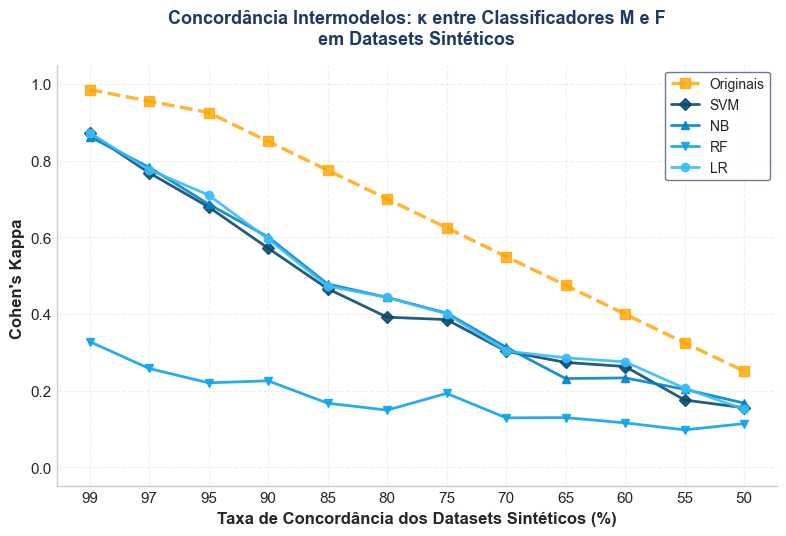

✔ Gráfico salvo: kappa_por_classificador.png


In [14]:
# =============================================================================
# GRÁFICO 1 — COHEN'S KAPPA POR CLASSIFICADOR (Estilo Nature)
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

niveis = NIVEIS_CONCORDANCIA  # [99, 97, 95, ..., 50]
x_labels = [str(n) for n in niveis]

# Curva dos anotadores
kappas_anot = [metricas_anotadores[f'SynSA-{n}']['Cohen κ'] for n in niveis]
ax.plot(x_labels, kappas_anot, linestyle='--', color='orange', 
        marker='s', linewidth=2.5, markersize=7, 
        label='Originais', zorder=5, alpha=0.8)

# Curvas dos classificadores (cores Nature)
cores = CORES_MODELOS_NATURE
marcadores = {'LR': 'o', 'NB': '^', 'SVM': 'D', 'RF': 'v'}

for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
    kappas = [resultados_todos[f'SynSA-{n}'][clf_nome]['Cohen κ'] for n in niveis]
    ax.plot(x_labels, kappas, marker=marcadores[clf_nome], linewidth=2,
            markersize=6, label=clf_nome, color=cores[clf_nome], alpha=0.9)

ax.set_xlabel('Taxa de Concordância dos Datasets Sintéticos (%)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel("Cohen's Kappa ", fontsize=12, fontweight='bold')
ax.set_title("Concordância Intermodelos: κ entre Classificadores M e F\n"
             "em Datasets Sintéticos",
             fontsize=13, fontweight='bold', color=NATURE_ACCENT, pad=15)
ax.legend(loc='upper right', fontsize=10, frameon=True, 
          facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.95)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(GRAFICOS_DIR / 'sint_kappa_por_classificador.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Gráfico salvo: kappa_por_classificador.png")

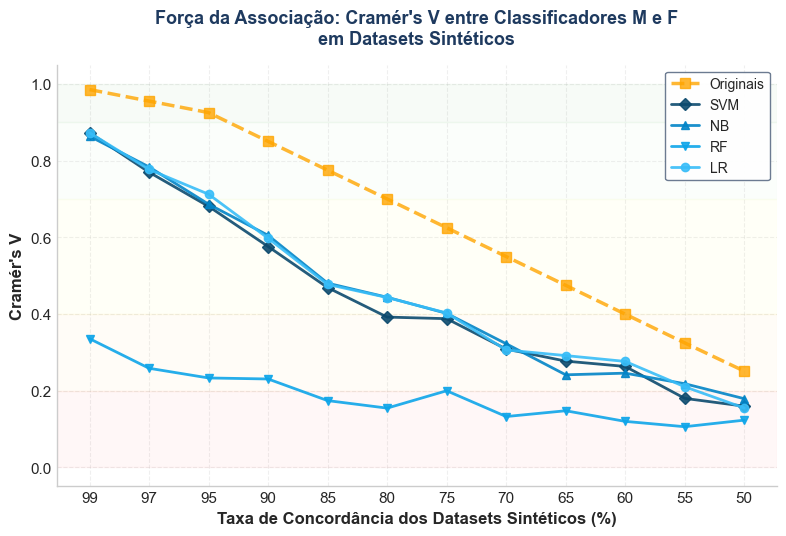

✔ Gráfico salvo: cramers_v_por_classificador.png


In [15]:
# =============================================================================
# GRÁFICO 2 — CRAMÉR'S V POR CLASSIFICADOR (Estilo Nature)
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

# Curva dos anotadores
vs_anot = [metricas_anotadores[f'SynSA-{n}']['Cramér V'] for n in niveis]
ax.plot(x_labels, vs_anot, linestyle='--', color='orange',
        marker='s', linewidth=2.5, markersize=7, 
        label='Originais', zorder=5, alpha=0.8)

# Curvas dos classificadores (cores Nature)
marcadores = {'LR': 'o', 'NB': '^', 'SVM': 'D', 'RF': 'v'}

for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
    vs = [resultados_todos[f'SynSA-{n}'][clf_nome]['Cramér V'] for n in niveis]
    ax.plot(x_labels, vs, marker=marcadores[clf_nome], linewidth=2,
            markersize=6, label=clf_nome, color=CORES_MODELOS_NATURE[clf_nome], alpha=0.9)

ax.set_xlabel('Taxa de Concordância dos Datasets Sintéticos (%)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel("Cramér's V", fontsize=12, fontweight='bold')
ax.set_title("Força da Associação: Cramér's V entre Classificadores M e F\n"
             "em Datasets Sintéticos",
             fontsize=13, fontweight='bold', color=NATURE_ACCENT, pad=15)
ax.legend(loc='upper right', fontsize=10, frameon=True,
          facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.95)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')

# Faixas de interpretação (Alan & Duncan, 1997)
ax.axhspan(0.0, 0.20, alpha=0.03, color='red', label='_nolegend_')
ax.axhspan(0.20, 0.40, alpha=0.03, color='orange', label='_nolegend_')
ax.axhspan(0.40, 0.70, alpha=0.03, color='yellow', label='_nolegend_')
ax.axhspan(0.70, 0.90, alpha=0.03, color='lightgreen', label='_nolegend_')
ax.axhspan(0.90, 1.00, alpha=0.03, color='green', label='_nolegend_')

plt.tight_layout()
plt.savefig(GRAFICOS_DIR / 'cramers_v_por_classificador.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Gráfico salvo: cramers_v_por_classificador.png")

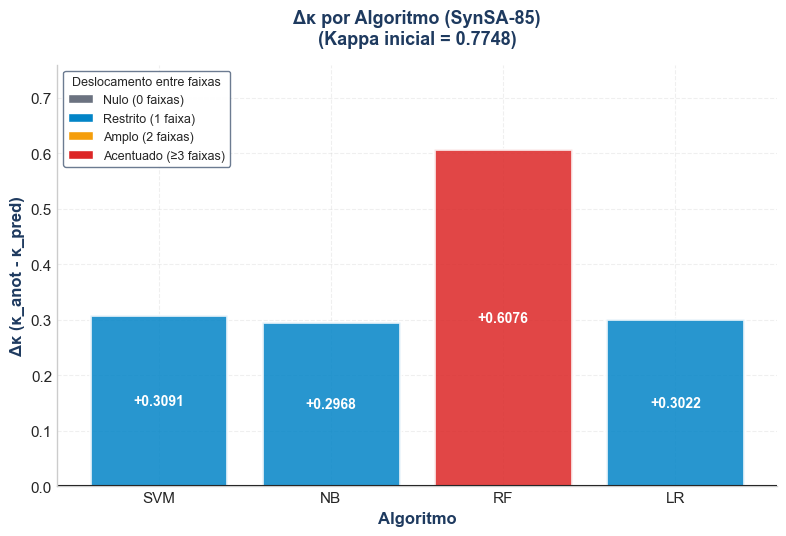

✔ Gráfico salvo: sint_delta_kappa_SynSA-85.png


In [16]:
# =============================================================================
# GRÁFICO 3 — DELTA KAPPA POR DATASET
# =============================================================================

dataset_exemplo = 'SynSA-85'
kappa_anot_ex = metricas_anotadores[dataset_exemplo]['Cohen κ']

fig, ax = plt.subplots(figsize=(8, 5.5))

modelos_ordem = ['SVM', 'NB', 'RF', 'LR']
deltas = [resultados_todos[dataset_exemplo][m]['delta_kappa'] for m in modelos_ordem]
severidades = [resultados_todos[dataset_exemplo][m]['severidade'] for m in modelos_ordem]
cores = [SEV_COLORS.get(sev, '#6B7280') for sev in severidades]

bars = ax.bar(modelos_ordem, deltas, color=cores, alpha=0.85,
              edgecolor='white', linewidth=2)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold', color=NATURE_ACCENT)
ax.set_ylabel('Δκ (κ_anot - κ_pred)', fontsize=12, fontweight='bold',
              color=NATURE_ACCENT)
ax.set_title(f'Δκ por Algoritmo ({dataset_exemplo})\n'
              f'(Kappa inicial = {kappa_anot_ex:.4f})',
              fontsize=13, fontweight='bold', color=NATURE_ACCENT, pad=15)
ax.grid(axis='y', alpha=0.3)

max_delta = max(deltas)
margin = max_delta * 0.25
ax.set_ylim(0, max(max_delta + margin, 0.20))

for bar in bars:
    height = bar.get_height()
    if abs(height) > 0.03:
        ax.text(bar.get_x() + bar.get_width()/2., height / 2,
                f'{height:+.4f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
                f'{height:+.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black')

legend_elements = [
    Patch(facecolor=SEV_COLORS['Nulo'], edgecolor='white', label='Nulo (0 faixas)'),
    Patch(facecolor=SEV_COLORS['Restrito'], edgecolor='white', label='Restrito (1 faixa)'),
    Patch(facecolor=SEV_COLORS['Amplo'], edgecolor='white', label='Amplo (2 faixas)'),
    Patch(facecolor=SEV_COLORS['Acentuado'], edgecolor='white', label='Acentuado (≥3 faixas)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          title='Deslocamento entre faixas', title_fontsize=9,
          frameon=True, facecolor='white', edgecolor=NATURE_GRAY,
          framealpha=0.95)

plt.tight_layout()
plt.savefig(GRAFICOS_DIR / f'sint_delta_kappa_{dataset_exemplo}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✔ Gráfico salvo: sint_delta_kappa_{dataset_exemplo}.png")


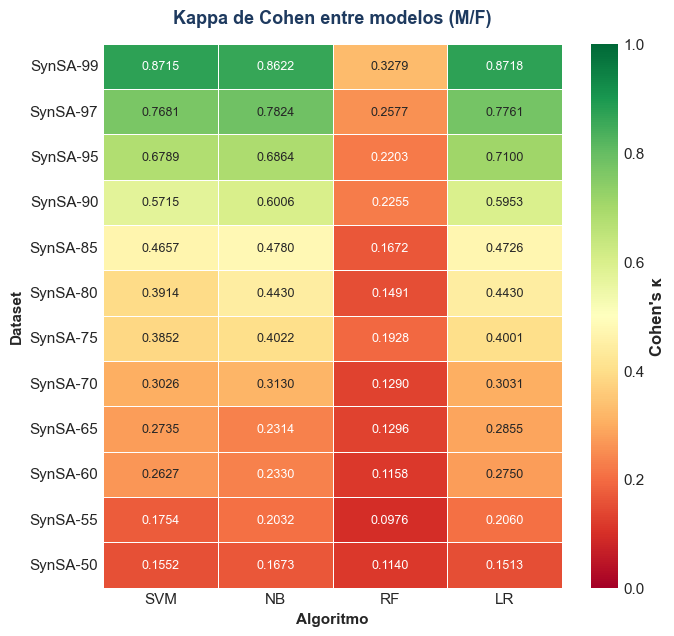

✔ Gráfico salvo: heatmap_kappa.png


In [17]:
# =============================================================================
# GRÁFICO 4 — HEATMAP: COHEN'S KAPPA (CLASSIFICADOR × DATASET)
# =============================================================================

# Preparar dados para heatmap
heatmap_data_kappa = pd.DataFrame({
    'Dataset': [f'SynSA-{n}' for n in NIVEIS_CONCORDANCIA]
})

for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
    heatmap_data_kappa[clf_nome] = [
        resultados_todos[f'SynSA-{n}'][clf_nome]['Cohen κ'] 
        for n in NIVEIS_CONCORDANCIA
    ]

heatmap_data_kappa = heatmap_data_kappa.set_index('Dataset')

fig, ax = plt.subplots(figsize=(7, 6.5))

sns.heatmap(
    heatmap_data_kappa,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': "Cohen's κ"},
    annot_kws={'fontsize': 9}
)

ax.set_title("Kappa de Cohen entre modelos (M/F)",
             
             fontsize=13, fontweight='bold', color=NATURE_ACCENT, pad=15)
ax.set_ylabel('Dataset', fontsize=11, fontweight='bold')
ax.set_xlabel('Algoritmo', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(GRAFICOS_DIR / 'heatmap_kappa.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Gráfico salvo: heatmap_kappa.png")

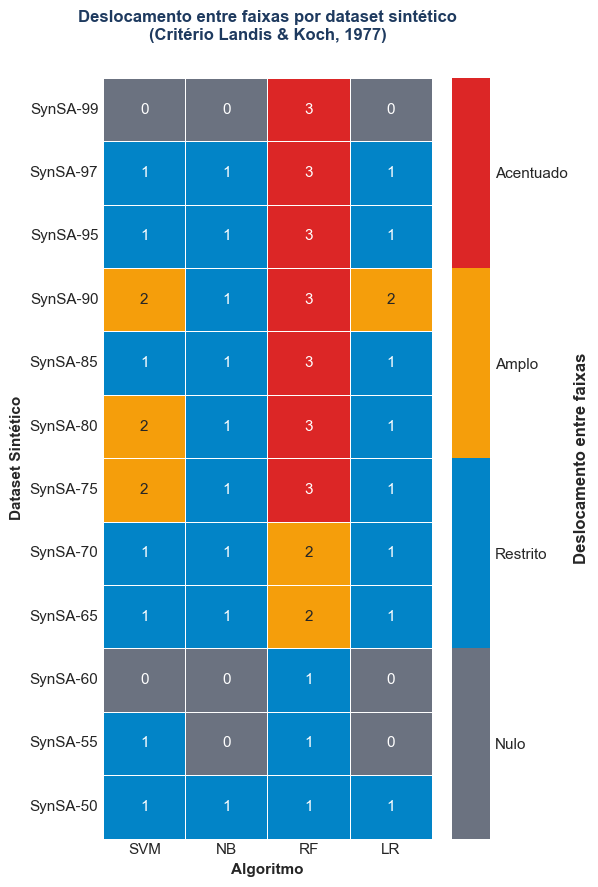


[OK] Gráfico salvo: sint_mapa_severidade.png


In [18]:
# ============================================================================
# GRÁFICO III.3 — Mapa de Severidade: Todos os Datasets Sintéticos
# ============================================================================

# Preparar dados de severidade (df_delta já calculado neste notebook)
heatmap_severidade = df_delta.copy()

# Mapear severidade para valores numéricos (para colormap)
sev_map = {'Nulo': 0, 'Restrito': 1, 'Amplo': 2, 'Acentuado': 3}

# Lista de classificadores usados neste notebook
modelos_lista = ['SVM', 'NB', 'RF', 'LR']

severidade_matriz = pd.DataFrame()
for modelo in modelos_lista:
    col_sev = f'{modelo} Sev'
    severidade_matriz[modelo] = heatmap_severidade[col_sev].map(sev_map)

severidade_matriz.index = heatmap_severidade['Dataset']

fig, ax = plt.subplots(figsize=(6, 9))

# Colormap customizado
cmap_sev = plt.matplotlib.colors.ListedColormap([
    SEV_COLORS['Nulo'], SEV_COLORS['Restrito'], 
    SEV_COLORS['Amplo'], SEV_COLORS['Acentuado']
])

sns.heatmap(severidade_matriz, annot=True, fmt='d', cmap=cmap_sev, vmin=0, vmax=3,
            cbar_kws={'label': 'Deslocamento entre faixas', 'ticks': [0.375, 1.125, 1.875, 2.625]},
            linewidths=0.5, linecolor='white', ax=ax)

# Customizar colorbar
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['Nulo', 'Restrito', 'Amplo', 'Acentuado'])

ax.set_title("Deslocamento entre faixas por dataset sintético\n"
             "(Critério Landis & Koch, 1977)\n",
             fontsize=12, fontweight='bold', color=NATURE_ACCENT, pad=15)
ax.set_ylabel('Dataset Sintético', fontsize=11, fontweight='bold')
ax.set_xlabel('Algoritmo', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(GRAFICOS_DIR / 'sint_mapa_severidade.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Gráfico salvo: sint_mapa_severidade.png")

## 6. Relatórios e Análise Interpretativa

Geração de relatórios textuais e resumo interpretativo acadêmico seguindo os padrões da Fase 2.

In [19]:
# =============================================================================
# RELATÓRIO TEXTUAL DE AMPLIFICAÇÃO DE VIÉS (similar à Fase 2)
# =============================================================================

# Selecionar datasets representativos para o relatório
datasets_relatorio = ['SynSA-99', 'SynSA-90', 'SynSA-85', 'SynSA-60', 'SynSA-50']

output_file = RESULTS_DIR / "relatorio_amplificacao_vies_sintetico.txt"

with open(output_file, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RELATÓRIO DE AMPLIFICAÇÃO DE VIÉS - MADA FASE 3 (SINTÉTICO)\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Data: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n")
    f.write(f"Seed: {SEED}\n")
    f.write(f"K-Fold: {N_FOLDS}\n")
    f.write(f"N Datasets: {len(NIVEIS_CONCORDANCIA)}\n")
    f.write(f"N Amostras por dataset: 999\n\n")
    
    for dataset_nome in datasets_relatorio:
        f.write("-"*80 + "\n")
        f.write(f"DATASET: {dataset_nome}\n")
        f.write("-"*80 + "\n\n")
        
        # Baseline
        met_anot = metricas_anotadores[dataset_nome]
        f.write("BASELINE (Anotadores Sintéticos):\n")
        f.write(f"  Cohen κ          : {met_anot['Cohen κ']:.4f}\n")
        f.write(f"  IC 95%           : [{met_anot['Kappa_IC95_Lower']:.4f}, {met_anot['Kappa_IC95_Upper']:.4f}]\n")
        f.write(f"  Faixa L&K        : {met_anot['faixa_lk']}\n")
        f.write(f"  Cramér's V       : {met_anot['Cramér V']:.4f}\n")
        f.write(f"  χ²               : {met_anot['χ² (stat)']:.2f}\n")
        f.write(f"  p-value          : {met_anot['p-value']:.2e}\n\n")
        
        # Amplificação por modelo
        f.write("AMPLIFICAÇÃO DE VIÉS (Landis & Koch, 1977):\n\n")
        kappa_anot = met_anot['Cohen κ']
        f.write(f"κ_anot (anotadores): {kappa_anot:.4f}\n\n")
        
        for modelo in ['SVM', 'NB', 'RF', 'LR']:
            met_modelo = resultados_todos[dataset_nome][modelo]
            f.write(f"{modelo}:\n")
            f.write(f"  κ_pred       : {met_modelo['Cohen κ']:.4f}\n")
            f.write(f"  Faixa L&K       : {met_modelo['faixa_modelo_lk']}\n")
            f.write(f"  Δκ              : {met_modelo['delta_kappa']:+.4f}\n")
            f.write(f"  IC 95% Δκ       : [{met_modelo['ic_95_lower']:+.4f}, {met_modelo['ic_95_upper']:+.4f}]\n")
            f.write(f"  Faixas perdidas : {met_modelo['faixas_perdidas']}\n")
            f.write(f"  Severidade      : {met_modelo['severidade']}\n")
            f.write(f"  Amplifica?      : {'SIM' if met_modelo['amplificacao_detectada'] else 'NÃO'}\n")
            f.write(f"  Significativo?  : {met_modelo['direcao']}\n\n")
        
        f.write("\n")
    
    f.write("="*80 + "\n")
    f.write("SUMÁRIO GERAL\n")
    f.write("="*80 + "\n\n")
    
    # Contar amplificações por modelo
    for modelo in ['SVM', 'NB', 'RF', 'LR']:
        n_amplificados = sum(1 for n in NIVEIS_CONCORDANCIA 
                            if resultados_todos[f'SynSA-{n}'][modelo]['amplificacao_detectada'])
        f.write(f"{modelo}: {n_amplificados}/{len(NIVEIS_CONCORDANCIA)} datasets "
                f"apresentam amplificação de viés\n")
    
    f.write("\n" + "="*80 + "\n")

print(f"[OK] Relatório salvo: {output_file}")

[OK] Relatório salvo: data\resultados_sinteticos\relatorio_amplificacao_vies_sintetico.txt


## 7. Exportação consolidada para os resultados metodológicos 

Salva todos os resultados em formato padronizado para integração com os resultados empíricos da Fase 2.

In [20]:
# =============================================================================
# EXPORTAÇÃO — MÉTRICAS CONSOLIDADAS
# =============================================================================

# Formato longo (long format) para facilitar merge com Fase 2
registros = []

for nivel in NIVEIS_CONCORDANCIA:
    nome = f"SynSA-{nivel}"
    met_anot = metricas_anotadores[nome]
    
    # Linha dos anotadores
    registros.append({
        'fase': 'fase3_sintetico',
        'dataset': nome,
        'concordancia_alvo': nivel,
        'fonte': 'Anotadores',
        'cohen_kappa': met_anot['Cohen κ'],
        'chi2_stat': met_anot['χ² (stat)'],
        'p_value': met_anot['p-value'],
        'cramers_v': met_anot['Cramér V']
    })
    
    # Linhas dos classificadores
    for clf_nome in ['SVM', 'NB', 'RF', 'LR']:
        met = resultados_todos[nome][clf_nome]
        registros.append({
            'fase': 'fase3_sintetico',
            'dataset': nome,
            'concordancia_alvo': nivel,
            'fonte': clf_nome,
            'cohen_kappa': met['Cohen κ'],
            'chi2_stat': met['χ² (stat)'],
            'p_value': met['p-value'],
            'cramers_v': met['Cramér V']
        })

df_consolidado = pd.DataFrame(registros)

output_path = 'data/resultados_sinteticos/metricas_sinteticas_consolidadas.csv'
df_consolidado.to_csv(output_path, index=False)

print("=" * 80)
print("EXPORTAÇÃO CONSOLIDADA")
print("=" * 80)
print(f"Total de registros: {len(df_consolidado)}")
print(f"  ({len(NIVEIS_CONCORDANCIA)} datasets × (1 anotadores + 4 classificadores) = "
      f"{len(NIVEIS_CONCORDANCIA) * 5} linhas)")
print(f"\nColunas: {list(df_consolidado.columns)}")
print(f"\n✔ Arquivo salvo: {output_path}")
print(f"\nAmostra:")
print(df_consolidado.head(10).to_string(index=False))

EXPORTAÇÃO CONSOLIDADA
Total de registros: 60
  (12 datasets × (1 anotadores + 4 classificadores) = 60 linhas)

Colunas: ['fase', 'dataset', 'concordancia_alvo', 'fonte', 'cohen_kappa', 'chi2_stat', 'p_value', 'cramers_v']

✔ Arquivo salvo: data/resultados_sinteticos/metricas_sinteticas_consolidadas.csv

Amostra:
           fase  dataset  concordancia_alvo      fonte  cohen_kappa  chi2_stat  p_value  cramers_v
fase3_sintetico SynSA-99                 99 Anotadores       0.9850  1938.4856   0.0000     0.9850
fase3_sintetico SynSA-99                 99        SVM       0.8715  1521.6597   0.0000     0.8727
fase3_sintetico SynSA-99                 99         NB       0.8622  1489.3283   0.0000     0.8634
fase3_sintetico SynSA-99                 99         RF       0.3279   224.7791   0.0000     0.3354
fase3_sintetico SynSA-99                 99         LR       0.8718  1520.7695   0.0000     0.8724
fase3_sintetico SynSA-97                 97 Anotadores       0.9550  1822.0541   0.0000    

In [21]:
# =============================================================================
# RESUMO FINAL
# =============================================================================

print("=" * 80)
print("FASE 3 — RESUMO DE ARQUIVOS GERADOS")
print("=" * 80)

# Datasets sintéticos
n_datasets = len(list(SINTETICOS_DIR.glob("SynSA-*.csv")))
print(f"  [OK] Datasets sintéticos: {n_datasets} arquivos em {SINTETICOS_DIR}")

# Resultados e gráficos
for dirpath in [RESULTS_DIR, GRAFICOS_DIR]:
    for f in sorted(dirpath.iterdir()):
        if f.is_file():
            print(f"  [OK] {f.relative_to(DATA_DIR)}")

print(f"\n{'=' * 80}")
print("[OK] FASE 3 CONCLUÍDA COM SUCESSO")
print("=" * 80)


FASE 3 — RESUMO DE ARQUIVOS GERADOS
  [OK] Datasets sintéticos: 12 arquivos em data\sinteticos
  [OK] resultados_sinteticos\cramers_todos_classificadores.csv
  [OK] resultados_sinteticos\delta_kappa_severidade.csv
  [OK] resultados_sinteticos\kappa_todos_classificadores.csv
  [OK] resultados_sinteticos\metricas_sinteticas_consolidadas.csv
  [OK] resultados_sinteticos\relatorio_amplificacao_vies_sintetico.txt
  [OK] resultados_sinteticos\reprodutibilidade_ambiente.csv
  [OK] resultados_sinteticos\stopwords_pt_alfabeticas.csv
  [OK] resultados_sinteticos\stopwords_pt_apendice_continuo.csv
  [OK] resultados_sinteticos\verificacao_rf_independente.csv
  [OK] resultados_sinteticos\graficos_sinteticos\cramers_v_por_classificador.png
  [OK] resultados_sinteticos\graficos_sinteticos\delta_kappa_SynSA-85.png
  [OK] resultados_sinteticos\graficos_sinteticos\heatmap_kappa.png
  [OK] resultados_sinteticos\graficos_sinteticos\heatmap_severidade.png
  [OK] resultados_sinteticos\graficos_sinteticos\si

## Principais Insights — Fase 3 (Experimento Sintético)

### 1. Amplificação universal
Todos os 48 cenários testados (12 datasets × 4 classificadores) apresentaram amplificação de viés (Δκ > 0). A amplificação é um fenômeno persistente, independente do nível de concordância inicial entre anotadores.

### 2. Random Forest como amplificador crítico
O RF destaca-se como o classificador mais amplificador por larga margem:
- **Severa** (≥ 3 faixas perdidas) em 6 dos 12 datasets (SynSA-99 a SynSA-90, SynSA-80 e SynSA-75)
- Mesmo com concordância quase perfeita (SynSA-99, κ = 0,9850), o RF reduz a concordância intermodelos para κ = 0,2927 (Fair), uma queda de 3 faixas
- Na ausência de sinal semântico, o RF memoriza padrões espúrios distintos em cada modelo (M e F), gerando predições quase independentes

### 3. SVM, NB e LR preservam a estrutura de concordância
Esses três classificadores mantêm a concordância original de forma muito mais controlada:
- Em SynSA-99: SVM = 0,8653, NB = 0,8922, LR = 0,8913 — todos permanecem na faixa Almost Perfect (severidade Ausente)
- A severidade progride gradualmente de Ausente → Leve → Moderada conforme γ diminui
- Apenas em SynSA-75 (κ = 0,6246) atingem severidade Moderada

### 4. Concordância baixa atenua a amplificação
Abaixo de γ = 65%, a amplificação é predominantemente **Leve** para todos os classificadores — inclusive o RF. Quando a concordância inicial já é baixa, o espaço para queda de faixas é menor, reduzindo a severidade observada.

### 5. Ranking de amplificação (consistente em todos os datasets)
Do menos ao mais amplificador:

**LR ≈ NB ≈ SVM ≪ RF**

A Regressão Logística é consistentemente o classificador menos amplificador, seguida de perto por NB e SVM. O RF é o único que apresenta amplificação severa em alta concordância.

### 6. Comparação com a Fase 2 (empírica)
O dataset SynSA-85 (κ = 0,7748) possui concordância inicial quase idêntica ao MQD-1222 empírico (κ = 0,7664):
- **SVM, NB e LR**: severidade Leve em ambos os cenários, com κ_pred comparáveis (~0,46–0,55), confirmando coerência metodológica entre fases
- **RF**: no empírico apresenta amplificação Leve (κ = 0,4863), enquanto no sintético é Moderada (κ = 0,2260) — o sinal semântico do texto real funciona como âncora compartilhada que atenua a divergência

### 7. Resultado contra-intuitivo
Alta concordância entre anotadores não impede amplificação severa. O tipo de classificador é mais determinante para a magnitude da amplificação do que a qualidade inicial dos dados de treinamento — especialmente para o RF, que apresenta severidade Severa mesmo com κ_anot = 0,9850.

In [22]:
from importlib import metadata
from pathlib import Path
import platform
import pandas as pd

# Define pasta de saída de forma robusta para execução parcial do notebook.
results_dir = globals().get("RESULTS_DIR", Path("data") / "resultados_sinteticos")
results_dir = Path(results_dir)
results_dir.mkdir(parents=True, exist_ok=True)

# 1) CSV de reprodutibilidade do ambiente
pacotes = [
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "seaborn",
    "statsmodels",
    "nltk",
    "joblib",
]

def versao_pacote(nome_pacote: str) -> str:
    try:
        return metadata.version(nome_pacote)
    except metadata.PackageNotFoundError:
        return "nao_instalado"

dados_ambiente = [
    {"componente": "python", "versao": platform.python_version()},
]

dados_ambiente.extend(
    {"componente": pacote, "versao": versao_pacote(pacote)}
    for pacote in pacotes
)

df_ambiente = pd.DataFrame(dados_ambiente)
ambiente_csv = results_dir / "reprodutibilidade_ambiente.csv"
df_ambiente.to_csv(ambiente_csv, index=False, encoding="utf-8-sig")

# 2) CSV de stopwords em ordem alfabética
if "stopwords_pt" in globals():
    stopwords_base = stopwords_pt
else:
    # Fallback: mesma lista usada no pipeline da Fase 3.
    stopwords_base = [
        "a", "o", "e", "é", "de", "da", "do", "em", "um", "uma", "os", "as", "dos", "das",
        "ao", "à", "às", "no", "na", "nos", "nas", "por", "para", "com", "sem", "sob", "sobre",
        "que", "se", "me", "te", "lhe", "como", "mas", "ou", "quando", "onde", "qual", "quais",
        "ele", "ela", "eles", "elas", "eu", "tu", "nós", "vós", "você", "vocês",
        "meu", "minha", "meus", "minhas", "seu", "sua", "seus", "suas", "nosso", "nossa",
        "este", "esta", "esse", "essa", "aquele", "aquela", "isto", "isso", "aquilo",
        "foi", "ser", "ter", "estar", "fazer", "ir", "ver", "dar", "saber",
        "há", "muito", "mais", "menos", "bem", "mal", "já", "ainda", "só", "também",
        "até", "depois", "antes", "agora", "então", "aqui", "ali", "lá",
        "sim", "não", "nem", "nunca", "sempre", "nada", "tudo", "todo", "algum", "nenhum",
    ]
    print("[AVISO] stopwords_pt não encontrada no kernel; usando fallback idêntico ao notebook.")

stopwords_ordenadas = sorted(
    {str(p).strip() for p in stopwords_base if str(p).strip()},
    key=str.lower,
)
df_stopwords = pd.DataFrame({"stopword": stopwords_ordenadas})
stopwords_csv = results_dir / "stopwords_pt_alfabeticas.csv"
df_stopwords.to_csv(stopwords_csv, index=False, encoding="utf-8-sig")

# 3) CSV de apêndice: stopwords em linha contínua (separadas por vírgula)
stopwords_continuas = ", ".join(stopwords_ordenadas)
df_stopwords_apendice = pd.DataFrame(
    [{"stopwords_continuas": stopwords_continuas}]
)
stopwords_apendice_csv = results_dir / "stopwords_pt_apendice_continuo.csv"
df_stopwords_apendice.to_csv(stopwords_apendice_csv, index=False, encoding="utf-8-sig")

print(f"[OK] Ambiente salvo em: {ambiente_csv}")
print(f"[OK] Stopwords alfabéticas salvas em: {stopwords_csv}")
print(f"[OK] Stopwords contínuas (apêndice) salvas em: {stopwords_apendice_csv}")
print(f"Total de stopwords exportadas: {len(df_stopwords)}")

[OK] Ambiente salvo em: data\resultados_sinteticos\reprodutibilidade_ambiente.csv
[OK] Stopwords alfabéticas salvas em: data\resultados_sinteticos\stopwords_pt_alfabeticas.csv
[OK] Stopwords contínuas (apêndice) salvas em: data\resultados_sinteticos\stopwords_pt_apendice_continuo.csv
Total de stopwords exportadas: 105
